# Scalability with Prefect: Distributed Bagged Posteriors

Under model misspecification, standard Bayesian posteriors can be unreliable. The **bagged posterior** ([Huggins & Miller, 2024](https://doi.org/10.1214/24-EJS2237)) fixes this by averaging over posteriors conditioned on bootstrapped datasets. Each bootstrap replicate requires a full MCMC fit — an embarrassingly parallel workload that is ideal for distribution.

This notebook shows how ProbPipe's **global Prefect configuration** distributes these fits automatically. The key idea: set orchestration once, and every `Function` in the system — including the one inside `condition_on` — uses it.

```python
import probpipe
from probpipe import WorkflowKind

probpipe.prefect_config.workflow_kind = WorkflowKind.TASK
```

We use the horseshoe crab satellite dataset from the [Getting Started tutorial](../tutorials/getting_started.ipynb), comparing a misspecified Poisson model against a well-specified negative binomial.

**Prerequisites:**
```bash
pip install probpipe[prefect]
# For Ray-based parallelism (optional):
pip install prefect-ray ray
```

In [1]:
import warnings
from typing import Any
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import time

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

import probpipe
from probpipe import (
    Distribution, Record, Normal, ProductDistribution,
    EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel, WorkflowKind,
    condition_on, mean, function,
    provenance_ancestors, workflow_run,
)

## 1. Data and models

We reuse the horseshoe crab satellite dataset and models from the Getting Started tutorial. The **Poisson** model is misspecified (can't capture overdispersion); the **negative binomial** is well-specified.

In [2]:
# Load data
df = pd.read_csv("../tutorials/data/horseshoe_crabs.csv")

@function
def prep_data(width, satellites) -> Record:
    width = np.asarray(width, dtype=np.float32)
    width_z = ((width - np.mean(width)) / np.std(width)).astype(np.float32)
    return Record("data", X=width_z, y=np.asarray(satellites, dtype=np.float32))

data = prep_data(df['width_cm'], df['satellites'])

# Shared prior
prior = ProductDistribution(
    Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)

# Two models: misspecified Poisson vs well-specified Negative Binomial
model_poisson = SimpleModel(prior, GLMLikelihood(tfp_glm.Poisson(), data["X"]), name='poisson')
model_nb = SimpleModel(prior, GLMLikelihood(tfp_glm.NegativeBinomial(), data["X"]), name='negbin')

print(f"Observations: {len(data['y'])}")
print(f"Models: {model_poisson.name}, {model_nb.name}")

Observations: 172
Models: poisson, negbin


## 2. Baseline: local threaded bagged posteriors

First we run with orchestration **off** and declare a small `Function` adapter with `dispatch="thread"`. The adapter calls `condition_on.apply(...)` for each already-materialized bootstrap dataset, giving us a true local-thread timing baseline. Workflow controls belong on the Function declaration; a `dispatch` keyword passed to `condition_on(...)` would instead be an inference kwarg.

In [3]:
# Ensure Prefect is OFF for the baseline
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

N_REPLICATES = 16
WORKFLOW_SEED = 2026

@function(dispatch="thread")
def fit_conditioned(
    dist: Distribution,
    observed: Any = None,
    *,
    method: str | None = None,
    **kwargs: Any,
) -> Distribution:
    return condition_on.apply(dist, observed, method=method, **kwargs)

bootstrap = BootstrapReplicateDistribution("bootstrap", EmpiricalDistribution("data", data))

with workflow_run(seed=WORKFLOW_SEED):
    t0 = time.perf_counter()
    bagged_poisson_seq = fit_conditioned.with_options(n_broadcast_samples=N_REPLICATES)(
        model_poisson, X=bootstrap["X"], y=bootstrap["y"],
    )
    t_poisson_seq = time.perf_counter() - t0

    t0 = time.perf_counter()
    bagged_nb_seq = fit_conditioned.with_options(n_broadcast_samples=N_REPLICATES)(
        model_nb, X=bootstrap["X"], y=bootstrap["y"],
    )
    t_nb_seq = time.perf_counter() - t0

print(f"Local threaded dispatch:")
print(f"  Poisson ({N_REPLICATES} replicates): {t_poisson_seq:.1f}s")
print(f"  NegBin  ({N_REPLICATES} replicates): {t_nb_seq:.1f}s")

Local threaded dispatch:
  Poisson (16 replicates): 9.3s
  NegBin  (16 replicates): 9.9s


## 3. Global Prefect configuration

Now the key step: **enable Prefect globally**. One line of config, and the same `fit_conditioned` Function dispatches each bootstrap MCMC fit as a Prefect task. The modeling call is identical — only the config changes. A Prefect workflow kind takes precedence over the adapter's local-thread transport.

`WorkflowKind` has four values:
- `DEFAULT` — inherit from global config (shipped default: `OFF`; set via `PROBPIPE_WORKFLOW_KIND` or `prefect_config.workflow_kind`)
- `TASK` — explicitly use Prefect tasks
- `FLOW` — explicitly use Prefect flows
- `OFF` — no Prefect, even if installed

In [4]:
from prefect.testing.utilities import prefect_test_harness

# Enable Prefect globally — one line, applies everywhere
probpipe.prefect_config.workflow_kind = WorkflowKind.TASK

# Same bootstrap distribution
bootstrap = BootstrapReplicateDistribution("bootstrap", EmpiricalDistribution("data", data))

# Use Prefect's test harness for an in-process ephemeral server.
# In production, need to run `prefect server start` instead.
with prefect_test_harness(), workflow_run(seed=WORKFLOW_SEED):
    t0 = time.perf_counter()
    bagged_poisson_pf = fit_conditioned.with_options(n_broadcast_samples=N_REPLICATES)(
        model_poisson, X=bootstrap["X"], y=bootstrap["y"],
    )
    t_poisson_pf = time.perf_counter() - t0

    t0 = time.perf_counter()
    bagged_nb_pf = fit_conditioned.with_options(n_broadcast_samples=N_REPLICATES)(
        model_nb, X=bootstrap["X"], y=bootstrap["y"],
    )
    t_nb_pf = time.perf_counter() - t0

print(f"Prefect task.map():")
print(f"  Poisson ({N_REPLICATES} replicates): {t_poisson_pf:.1f}s (local threaded was {t_poisson_seq:.1f}s)")
print(f"  NegBin  ({N_REPLICATES} replicates): {t_nb_pf:.1f}s (local threaded was {t_nb_seq:.1f}s)")

22:14:38.001 | INFO    | prefect - Starting temporary server on http://127.0.0.1:62433
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

/private/tmp/claude-503/-Users-jhuggins-Dropbox-Research-Projects--public-repos-prob-pipe--claude-worktrees-issue-395-plan-pr-scope-a2c4c4/9393edca-7721-4422-b601-d7f28b21a531/scratchpad/a1_name/probpipe/core/_workflow_distribution_broadcast.py:480: UserWarning: dispatch='thread' and max_workers configure only local ThreadPoolExecutor dispatch; they do not control Prefect scheduling.
  execution = make_execution_config()


22:14:43.801 | INFO    | Flow run 'ambrosial-perch' - Beginning flow run 'ambrosial-perch' for flow 'fit_conditioned_map'

22:14:43.803 | INFO    | Flow run 'ambrosial-perch' - View at http://127.0.0.1:62433/runs/flow-run/a4fa27cd-d07d-4deb-bad9-1809d954987c

22:14:47.454 | INFO    | Task run 'fit_conditioned-01a' - Finished in state Completed()

...

22:15:01.484 | INFO    | Task run 'fit_conditioned-696' - Finished in state Completed()

22:15:01.610 | INFO    | Task run 'fit_conditioned-8b2' - Finished in state Completed()

22:15:02.036 | INFO    | Flow run 'delightful-chachalaca' - Finished in state Completed()

22:15:02.046 | INFO    | prefect - Stopping temporary server on http://127.0.0.1:62433

Prefect task.map():
  Poisson (16 replicates): 8.2s (local threaded was 9.3s)
  NegBin  (16 replicates): 10.2s (local threaded was 9.9s)


## 4. Validate correctness

The Prefect-distributed bagged posteriors should produce equivalent results to the local threaded baseline. We compare sampling variability ratios — the diagnostic that detects model misspecification.

In [5]:
# Turn Prefect off for post-processing (the test harness has shut down)
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF

def sampling_variability_ratio(bagged):
    """Var(individual means) / Var(bagged posterior). >0.5 = unstable."""
    # Per-replicate posterior means: (n_replicates, n_fields)
    ind_means = np.stack([
        np.asarray(p.flat_samples).mean(axis=0) for p in bagged.components
    ])
    # Pooled flat draws across replicates: (sum_n, n_fields)
    all_draws = np.concatenate([
        np.asarray(p.flat_samples) for p in bagged.components
    ])
    return np.var(ind_means, axis=0) / np.var(all_draws, axis=0)

print("Sampling variability ratios (>0.5 = misspecification):\n")
for label, seq, pf in [('Poisson', bagged_poisson_seq, bagged_poisson_pf),
                        ('NegBin', bagged_nb_seq, bagged_nb_pf)]:
    r_seq = sampling_variability_ratio(seq)
    r_pf = sampling_variability_ratio(pf)
    print(f"  {label}:")
    print(f"    Local threaded: {np.array2string(r_seq, precision=3)}")
    print(f"    Prefect:    {np.array2string(r_pf, precision=3)}")

Sampling variability ratios (>0.5 = misspecification):

  Poisson:
    Local threaded: [0.756 0.801]
    Prefect:    [0.756 0.801]
  NegBin:
    Local threaded: [0.533 0.412]
    Prefect:    [0.533 0.412]


Both routes use the same workflow seed and call structure. ProbPipe therefore assigns the bootstrap sources and logical replicate units the same structural RNG identities even though one run uses local threads and the other uses Prefect tasks. Route-specific libraries, scheduling, and floating-point reductions may still differ, so this is a logical reproducibility contract rather than a promise of bit-identical numerical output. The inference backend's explicit `random_seed` remains a separate caller-owned algorithm input.

## 5. Provenance tracking

Provenance captures the orchestration mode in descriptive metadata and the actual evaluator/transport route in diagnostics. The Prefect-distributed result records `"task"` in its metadata, while the local threaded baseline records `"off"`. These route observations do not define RNG identity.

ProbPipe-managed retries keep the immutable work-item identity and reuse its workflow key. They do **not** provide exactly-once user side effects: a failed attempt may run user code again. Concurrency must also enter through a managed route. Copying an active ContextVar into an arbitrary external thread or asyncio task and then requesting automatic randomness is rejected; a thread that receives no copied context starts an independent ephemeral run.

In [6]:
for label, bagged in [("Local threaded", bagged_nb_seq), ("Prefect", bagged_nb_pf)]:
    src = bagged.provenance
    print(f"{label}:")
    print(f"  Operation:   {src.operation}")
    print(f"  Orchestrate: {src.metadata['orchestrate']}")
    print(f"  N samples:   {src.metadata['n_samples']}")
    print(f"  Execution:   {src.diagnostics.get('execution', [])}")
    print()

Local threaded:
  Operation:   broadcast
  Orchestrate: off
  N samples:   16
  Execution:   [{'requested_dispatch': 'thread', 'requested_workflow_kind': 'off', 'resolved_evaluator': 'rowwise', 'resolved_transport': 'local_thread', 'contract_abi': 'probpipe.workflow_rng_execution/v1'}]

Prefect:
  Operation:   broadcast
  Orchestrate: task
  N samples:   16
  Execution:   [{'requested_dispatch': 'thread', 'requested_workflow_kind': 'task', 'resolved_evaluator': 'rowwise', 'resolved_transport': 'prefect_task', 'contract_abi': 'probpipe.workflow_rng_execution/v1'}]



## 6. Visualize bagged posteriors

The Prefect-distributed results tell the same story as the local threaded baseline: Poisson individual posteriors spread apart (misspecified), negative binomial posteriors cluster tightly (well-specified).

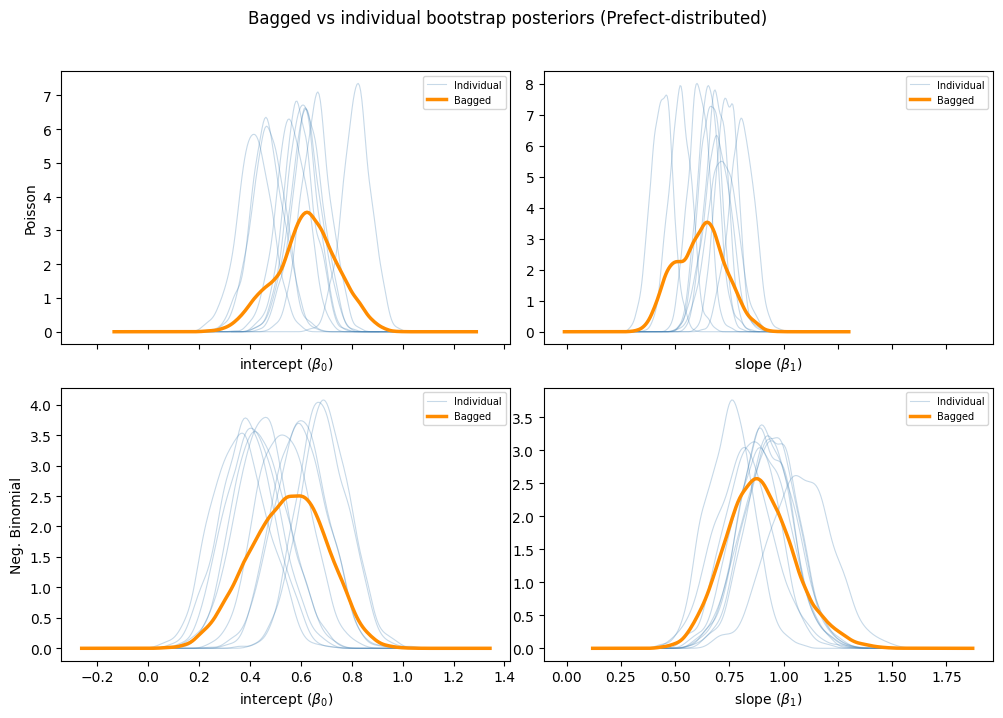

In [7]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex='col')

for row, (bagged, label) in enumerate([(bagged_poisson_pf, 'Poisson'),
                                        (bagged_nb_pf, 'Neg. Binomial')]):
    for col, name in enumerate(['intercept', 'slope']):
        param_label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
        ax = axes[row, col]
        for i, post in enumerate(bagged.components[:10]):
            d = np.asarray(post.draws()[name])
            xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
            ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color='steelblue',
                    label='Individual' if i == 0 else None)
        bd = np.concatenate([np.asarray(p.draws()[name]) for p in bagged.components])
        xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(bd)(xs), color='darkorange', lw=2.5, label='Bagged')
        ax.set(xlabel=param_label); ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label)

plt.suptitle('Bagged vs individual bootstrap posteriors (Prefect-distributed)', y=1.02)
plt.tight_layout(); plt.show()

## 7. Global off switch and per-instance override

The global config can be changed at any time. Here we demonstrate turning Prefect off globally, and overriding per-instance.

In [8]:
# Demonstrate global vs per-instance vs env-var resolution
probpipe.prefect_config.workflow_kind = WorkflowKind.OFF
print(f"Global config: {probpipe.prefect_config.workflow_kind}")

# A Function with DEFAULT inherits the global setting
from probpipe.core.node import Function

def add_one(x):
    return x + 1.0

wf_default = Function(func=add_one)
print(f"DEFAULT instance resolves to: {wf_default.effective_workflow_kind}")

# A per-instance TASK override still uses Prefect
wf_task = Function(func=add_one, workflow_kind=WorkflowKind.TASK)
print(f"Explicit TASK instance resolves to: {wf_task.effective_workflow_kind}")

# `reset()` returns to the shipped default (OFF) — or whatever
# `PROBPIPE_WORKFLOW_KIND` is set to in the environment.
probpipe.prefect_config.reset()
print(f"\nAfter reset, global is: {probpipe.prefect_config.workflow_kind}")
print(f"DEFAULT instance now resolves to: {wf_default.effective_workflow_kind}")

Global config: WorkflowKind.OFF
DEFAULT instance resolves to: WorkflowKind.OFF
Explicit TASK instance resolves to: WorkflowKind.TASK

After reset, global is: WorkflowKind.OFF
DEFAULT instance now resolves to: WorkflowKind.OFF


## 8. Task runner configuration

For true parallelism (beyond Prefect's in-process default), ProbPipe auto-detects installed runner packages. If `prefect-ray` is installed, `RayTaskRunner` is used automatically. You can also set it explicitly for remote clusters:

```python
from prefect_ray import RayTaskRunner

# Auto-detected (if prefect-ray is installed):
print(probpipe.prefect_config.resolve_task_runner())

# Explicit remote cluster:
probpipe.prefect_config.task_runner = RayTaskRunner(address="ray://cluster:10001")
```

Auto-detection priority: **Ray > Dask > Prefect default**.

In [9]:
# Show what task runner is currently auto-detected
runner = probpipe.prefect_config.resolve_task_runner()
print(f"Auto-detected task runner: {runner}")
print(f"Explicit task runner: {probpipe.prefect_config.task_runner}")

Auto-detected task runner: None
Explicit task runner: None
